In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make plots look decent
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

# Your Excel file path
excel_path = Path(r"C:\Users\ellio\Downloads\inv theory data.xlsx")

# Check that the file exists
excel_path, excel_path.exists()


(WindowsPath('C:/Users/ellio/Downloads/inv theory data.xlsx'), True)

In [7]:
# STEP 2: Inspect sheet names in the Excel file
xls = pd.ExcelFile(excel_path)
xls.sheet_names


['Sheet3',
 'DATA',
 'FTSEPA1 SJ Equity',
 'NEDGRPR SJ Equity',
 'OLDMAGA SJ Equity',
 'OLMEEAZ SJ Equity',
 'PRUHYBF SJ Equity']

In [8]:
# STEP 3: Load a single fund sheet and inspect it

fund_name = "FTSEPA1 SJ Equity"

ftse = pd.read_excel(
    excel_path,
    sheet_name=fund_name,
    parse_dates=["Dates"]   # make sure Dates is a datetime
)

print("Shape:", ftse.shape)
print("\nColumns:", ftse.columns.tolist())
print("\nData types:")
print(ftse.dtypes)

print("\nFirst 5 rows:")
ftse.head()


Shape: (764, 5)

Columns: ['Dates', 'FUND_NET_ASSET_VAL', 'MOV_AVG_50D', 'MOV_AVG_200D', 'RSI_14D']

Data types:
Dates                 datetime64[ns]
FUND_NET_ASSET_VAL           float64
MOV_AVG_50D                  float64
MOV_AVG_200D                 float64
RSI_14D                      float64
dtype: object

First 5 rows:


,Dates,FUND_NET_ASSET_VAL,MOV_AVG_50D,MOV_AVG_200D,RSI_14D
0,2023-01-03,170.40,170.6884,162.6484,40.0338
1,2023-01-04,170.37,170.9026,162.7352,39.9202
2,2023-01-05,173.03,171.1538,162.7885,52.7278
3,2023-01-06,173.71,171.4080,162.8392,55.3483
4,2023-01-09,176.24,171.7102,162.8919,63.4636


In [9]:
# STEP 4: Load all 5 funds into a dictionary

fund_names = [
    "FTSEPA1 SJ Equity",
    "NEDGRPR SJ Equity",
    "OLDMAGA SJ Equity",
    "OLMEEAZ SJ Equity",
    "PRUHYBF SJ Equity"
]

funds = {}

for name in fund_names:
    df = pd.read_excel(
        excel_path,
        sheet_name=name,
        parse_dates=["Dates"]
    ).sort_values("Dates")
    df["symbol"] = name
    funds[name] = df

# Quick overview: show shape for each
for name, df in funds.items():
    print(name, "->", df.shape)

# And preview the first fund
funds["FTSEPA1 SJ Equity"].head()


FTSEPA1 SJ Equity -> (764, 6)
NEDGRPR SJ Equity -> (764, 6)
OLDMAGA SJ Equity -> (764, 6)
OLMEEAZ SJ Equity -> (764, 6)
PRUHYBF SJ Equity -> (764, 6)


,Dates,FUND_NET_ASSET_VAL,MOV_AVG_50D,MOV_AVG_200D,RSI_14D,symbol
0,2023-01-03,170.40,170.6884,162.6484,40.0338,FTSEPA1 SJ Equity
1,2023-01-04,170.37,170.9026,162.7352,39.9202,FTSEPA1 SJ Equity
2,2023-01-05,173.03,171.1538,162.7885,52.7278,FTSEPA1 SJ Equity
3,2023-01-06,173.71,171.4080,162.8392,55.3483,FTSEPA1 SJ Equity
4,2023-01-09,176.24,171.7102,162.8919,63.4636,FTSEPA1 SJ Equity


In [10]:
# STEP 5: Add MACD and Bollinger Bands to each fund

def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add MACD and Bollinger Bands to an already cleaned fund DataFrame.
    Assumes df has columns: Dates, FUND_NET_ASSET_VAL, MOV_AVG_50D, MOV_AVG_200D, RSI_14D, symbol.
    """
    df = df.sort_values("Dates").copy()
    price = df["FUND_NET_ASSET_VAL"]

    # ----- MACD (12, 26, 9) -----
    ema12 = price.ewm(span=12, adjust=False).mean()
    ema26 = price.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    hist = macd - signal

    df["MACD"] = macd
    df["MACD_signal"] = signal
    df["MACD_hist"] = hist

    # ----- Bollinger Bands (20 day) -----
    ma20 = price.rolling(window=20, min_periods=20).mean()
    std20 = price.rolling(window=20, min_periods=20).std()

    df["BB_MA20"] = ma20
    df["BB_upper"] = ma20 + 2 * std20
    df["BB_lower"] = ma20 - 2 * std20

    return df

# Apply to all funds
funds_ind = {name: add_indicators(df) for name, df in funds.items()}

# Inspect one (FTSEPA1)
funds_ind["FTSEPA1 SJ Equity"].head()


,Dates,FUND_NET_ASSET_VAL,MOV_AVG_50D,MOV_AVG_200D,RSI_14D,symbol,MACD,MACD_signal,MACD_hist,BB_MA20,BB_upper,BB_lower
0,2023-01-03,170.40,170.6884,162.6484,40.0338,FTSEPA1 SJ Equity,0.000000,0.000000,0.000000,NaN,NaN,NaN
1,2023-01-04,170.37,170.9026,162.7352,39.9202,FTSEPA1 SJ Equity,-0.002393,-0.000479,-0.001915,NaN,NaN,NaN
2,2023-01-05,173.03,171.1538,162.7885,52.7278,FTSEPA1 SJ Equity,0.207953,0.041208,0.166745,NaN,NaN,NaN
3,2023-01-06,173.71,171.4080,162.8392,55.3483,FTSEPA1 SJ Equity,0.424629,0.117892,0.306737,NaN,NaN,NaN
4,2023-01-09,176.24,171.7102,162.8919,63.4636,FTSEPA1 SJ Equity,0.791374,0.252588,0.538786,NaN,NaN,NaN


In [11]:
# STEP 6: Add trading-style signals to each fund

def add_signals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add trading-style signals using MAs, RSI, MACD and Bollinger Bands.
    Assumes df already has MACD and Bollinger columns from add_indicators.
    """
    df = df.sort_values("Dates").copy()

    # Ensure required columns are numeric
    for col in ["MOV_AVG_50D", "MOV_AVG_200D", "RSI_14D", "MACD", "MACD_signal"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Initialise signal columns as object (string-friendly)
    df["MA_signal"] = pd.Series(index=df.index, dtype="object")
    df["RSI_signal"] = pd.Series(index=df.index, dtype="object")
    df["MACD_signal_type"] = pd.Series(index=df.index, dtype="object")
    df["BB_touch"] = pd.Series(index=df.index, dtype="object")

    # ---------- 1. Moving average crossover (50D vs 200D) ----------
    ma_short = df["MOV_AVG_50D"]
    ma_long = df["MOV_AVG_200D"]

    prev_diff = (ma_short - ma_long).shift(1)
    curr_diff = ma_short - ma_long

    # Bullish crossover: previously <= 0, now > 0
    df.loc[(prev_diff <= 0) & (curr_diff > 0), "MA_signal"] = "Bullish crossover (Buy)"

    # Bearish crossover: previously >= 0, now < 0
    df.loc[(prev_diff >= 0) & (curr_diff < 0), "MA_signal"] = "Bearish crossover (Sell)"

    # ---------- 2. RSI signals ----------
    rsi = df["RSI_14D"]
    prev_rsi = rsi.shift(1)

    # Exits oversold (crosses up through 30)
    df.loc[(prev_rsi < 30) & (rsi >= 30), "RSI_signal"] = "RSI exits oversold (Buy)"

    # Exits overbought (crosses down through 70)
    df.loc[(prev_rsi > 70) & (rsi <= 70), "RSI_signal"] = "RSI exits overbought (Sell)"

    # ---------- 3. MACD signals ----------
    prev_macd_diff = (df["MACD"] - df["MACD_signal"]).shift(1)
    curr_macd_diff = df["MACD"] - df["MACD_signal"]

    df.loc[(prev_macd_diff <= 0) & (curr_macd_diff > 0), "MACD_signal_type"] = "Bullish MACD crossover (Buy)"
    df.loc[(prev_macd_diff >= 0) & (curr_macd_diff < 0), "MACD_signal_type"] = "Bearish MACD crossover (Sell)"

    # ---------- 4. Bollinger band touches ----------
    price = df["FUND_NET_ASSET_VAL"]

    df.loc[price >= df["BB_upper"], "BB_touch"] = "Touches upper band (Overbought zone)"
    df.loc[price <= df["BB_lower"], "BB_touch"] = "Touches lower band (Oversold zone)"

    return df

# Apply to all indicator-enriched funds
funds_ta = {name: add_signals(df) for name, df in funds_ind.items()}

# Inspect FTSEPA1 with signals
funds_ta["FTSEPA1 SJ Equity"].head()


,Dates,FUND_NET_ASSET_VAL,MOV_AVG_50D,MOV_AVG_200D,RSI_14D,symbol,MACD,MACD_signal,MACD_hist,BB_MA20,BB_upper,BB_lower,MA_signal,RSI_signal,MACD_signal_type,BB_touch
0,2023-01-03,170.40,170.6884,162.6484,40.0338,FTSEPA1 SJ Equity,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-04,170.37,170.9026,162.7352,39.9202,FTSEPA1 SJ Equity,-0.002393,-0.000479,-0.001915,NaN,NaN,NaN,NaN,NaN,Bearish MACD crossover (Sell),NaN
2,2023-01-05,173.03,171.1538,162.7885,52.7278,FTSEPA1 SJ Equity,0.207953,0.041208,0.166745,NaN,NaN,NaN,NaN,NaN,Bullish MACD crossover (Buy),NaN
3,2023-01-06,173.71,171.4080,162.8392,55.3483,FTSEPA1 SJ Equity,0.424629,0.117892,0.306737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-09,176.24,171.7102,162.8919,63.4636,FTSEPA1 SJ Equity,0.791374,0.252588,0.538786,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# STEP 7: See the key signal dates for FTSEPA1 SJ Equity

ftse = funds_ta["FTSEPA1 SJ Equity"].sort_values("Dates").copy()

# Mask: any of the signal columns is not NaN
signal_mask = ftse[["MA_signal", "RSI_signal", "MACD_signal_type", "BB_touch"]].notna().any(axis=1)

ftse_signals = ftse.loc[signal_mask, [
    "Dates",
    "FUND_NET_ASSET_VAL",
    "MA_signal",
    "RSI_signal",
    "MACD_signal_type",
    "BB_touch"
]]

# Show the first 10 and last 10 signal rows
print("First signal rows:")
display(ftse_signals.head(10))

print("\nLast signal rows:")
display(ftse_signals.tail(10))


First signal rows:


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
1,2023-01-04,170.37,NaN,NaN,Bearish MACD crossover (Sell),NaN
2,2023-01-05,173.03,NaN,NaN,Bullish MACD crossover (Buy),NaN
12,2023-01-19,179.61,NaN,RSI exits overbought (Sell),NaN,NaN
16,2023-01-25,181.19,NaN,RSI exits overbought (Sell),NaN,NaN
19,2023-01-30,182.58,NaN,RSI exits overbought (Sell),NaN,NaN
23,2023-02-03,183.35,NaN,NaN,Bearish MACD crossover (Sell),NaN
32,2023-02-16,185.45,NaN,NaN,NaN,Touches upper band (Overbought zone)
48,2023-03-10,181.43,NaN,NaN,NaN,Touches lower band (Oversold zone)
49,2023-03-13,180.55,NaN,NaN,NaN,Touches lower band (Oversold zone)
51,2023-03-15,177.83,NaN,NaN,NaN,Touches lower band (Oversold zone)



Last signal rows:


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
703,2025-09-12,244.00,NaN,NaN,NaN,Touches upper band (Overbought zone)
704,2025-09-15,242.29,NaN,RSI exits overbought (Sell),NaN,NaN
709,2025-09-22,238.77,NaN,NaN,Bearish MACD crossover (Sell),NaN
721,2025-10-08,238.82,NaN,NaN,Bullish MACD crossover (Buy),NaN
723,2025-10-10,245.18,NaN,NaN,NaN,Touches upper band (Overbought zone)
738,2025-10-31,243.59,NaN,NaN,Bearish MACD crossover (Sell),NaN
746,2025-11-12,249.47,NaN,NaN,Bullish MACD crossover (Buy),NaN
747,2025-11-13,250.93,NaN,NaN,NaN,Touches upper band (Overbought zone)
749,2025-11-17,251.89,NaN,NaN,NaN,Touches upper band (Overbought zone)
754,2025-11-24,247.33,NaN,NaN,Bearish MACD crossover (Sell),NaN


In [13]:
# STEP 8: Show recent signals for ALL funds

def get_signal_table(df: pd.DataFrame, last_n: int = 8) -> pd.DataFrame:
    """Return the last_n rows where any signal is present."""
    mask = df[["MA_signal", "RSI_signal", "MACD_signal_type", "BB_touch"]].notna().any(axis=1)
    sigs = df.loc[mask, [
        "Dates",
        "FUND_NET_ASSET_VAL",
        "MA_signal",
        "RSI_signal",
        "MACD_signal_type",
        "BB_touch"
    ]]
    return sigs.tail(last_n)

for name, df in funds_ta.items():
    print(f"\n================ {name} ================")
    display(get_signal_table(df, last_n=8))



================ FTSEPA1 SJ Equity ================


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
709,2025-09-22,238.77,NaN,NaN,Bearish MACD crossover (Sell),NaN
721,2025-10-08,238.82,NaN,NaN,Bullish MACD crossover (Buy),NaN
723,2025-10-10,245.18,NaN,NaN,NaN,Touches upper band (Overbought zone)
738,2025-10-31,243.59,NaN,NaN,Bearish MACD crossover (Sell),NaN
746,2025-11-12,249.47,NaN,NaN,Bullish MACD crossover (Buy),NaN
747,2025-11-13,250.93,NaN,NaN,NaN,Touches upper band (Overbought zone)
749,2025-11-17,251.89,NaN,NaN,NaN,Touches upper band (Overbought zone)
754,2025-11-24,247.33,NaN,NaN,Bearish MACD crossover (Sell),NaN



================ NEDGRPR SJ Equity ================


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
720,2025-10-07,77.96,NaN,NaN,Bullish MACD crossover (Buy),Touches upper band (Overbought zone)
721,2025-10-08,78.30,NaN,NaN,NaN,Touches upper band (Overbought zone)
723,2025-10-10,79.40,NaN,NaN,NaN,Touches upper band (Overbought zone)
724,2025-10-13,79.38,NaN,NaN,NaN,Touches upper band (Overbought zone)
726,2025-10-15,79.09,NaN,RSI exits overbought (Sell),NaN,NaN
747,2025-11-13,87.26,NaN,NaN,NaN,Touches upper band (Overbought zone)
760,2025-12-02,88.51,NaN,NaN,Bearish MACD crossover (Sell),NaN
763,2025-12-05,88.50,NaN,RSI exits overbought (Sell),NaN,NaN



================ OLDMAGA SJ Equity ================


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
723,2025-10-10,4854.44,NaN,RSI exits overbought (Sell),Bearish MACD crossover (Sell),NaN
727,2025-10-16,5388.32,NaN,NaN,NaN,Touches upper band (Overbought zone)
728,2025-10-17,5417.58,NaN,NaN,Bullish MACD crossover (Buy),Touches upper band (Overbought zone)
729,2025-10-20,5152.99,NaN,RSI exits overbought (Sell),Bearish MACD crossover (Sell),NaN
731,2025-10-22,4549.97,NaN,NaN,NaN,Touches lower band (Oversold zone)
735,2025-10-28,4470.28,NaN,NaN,NaN,Touches lower band (Oversold zone)
745,2025-11-11,5095.90,NaN,NaN,Bullish MACD crossover (Buy),NaN
747,2025-11-13,5419.50,NaN,NaN,NaN,Touches upper band (Overbought zone)



================ OLMEEAZ SJ Equity ================


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
717,2025-10-02,369.48,NaN,NaN,NaN,Touches upper band (Overbought zone)
721,2025-10-08,375.21,NaN,NaN,NaN,Touches upper band (Overbought zone)
725,2025-10-14,373.06,NaN,RSI exits overbought (Sell),NaN,NaN
728,2025-10-17,373.84,NaN,RSI exits overbought (Sell),Bearish MACD crossover (Sell),NaN
740,2025-11-04,363.16,NaN,NaN,NaN,Touches lower band (Oversold zone)
746,2025-11-12,377.61,NaN,NaN,Bullish MACD crossover (Buy),NaN
747,2025-11-13,386.49,NaN,NaN,NaN,Touches upper band (Overbought zone)
753,2025-11-21,368.36,NaN,NaN,Bearish MACD crossover (Sell),NaN



================ PRUHYBF SJ Equity ================


,Dates,FUND_NET_ASSET_VAL,MA_signal,RSI_signal,MACD_signal_type,BB_touch
747,2025-11-13,143.68,NaN,NaN,NaN,Touches upper band (Overbought zone)
748,2025-11-14,143.40,NaN,NaN,NaN,Touches upper band (Overbought zone)
749,2025-11-17,144.07,NaN,NaN,NaN,Touches upper band (Overbought zone)
755,2025-11-25,143.42,NaN,RSI exits overbought (Sell),NaN,NaN
756,2025-11-26,143.95,NaN,NaN,Bearish MACD crossover (Sell),NaN
758,2025-11-28,144.96,NaN,NaN,Bullish MACD crossover (Buy),NaN
761,2025-12-03,146.80,NaN,NaN,NaN,Touches upper band (Overbought zone)
762,2025-12-04,147.08,NaN,NaN,NaN,Touches upper band (Overbought zone)



================ FTSEPA1 SJ Equity ================



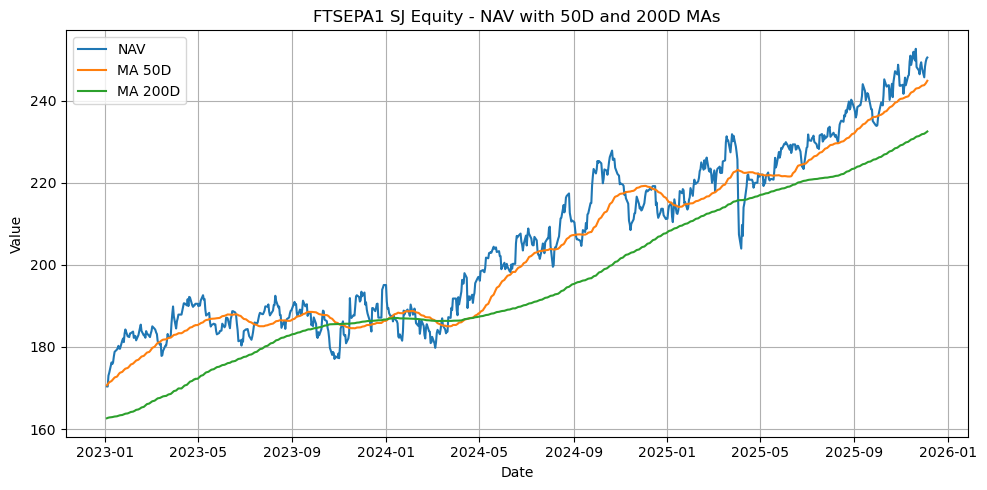

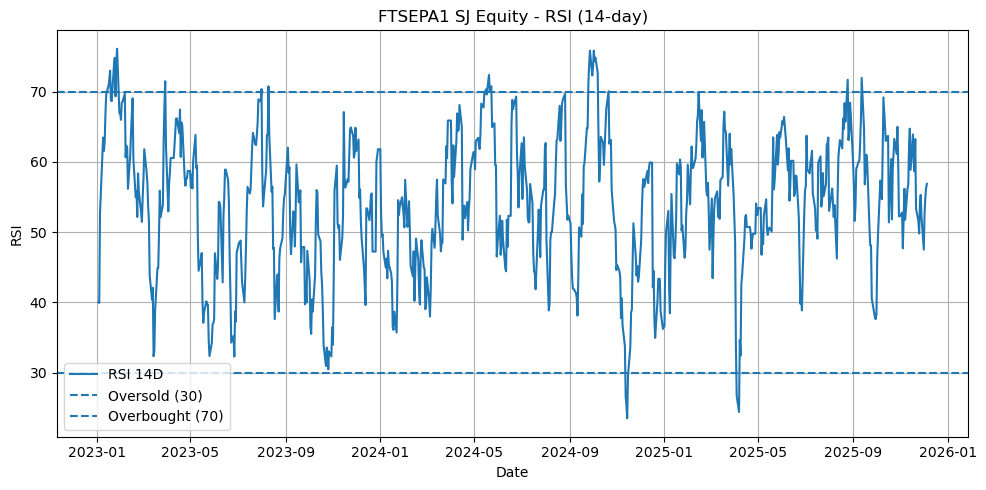

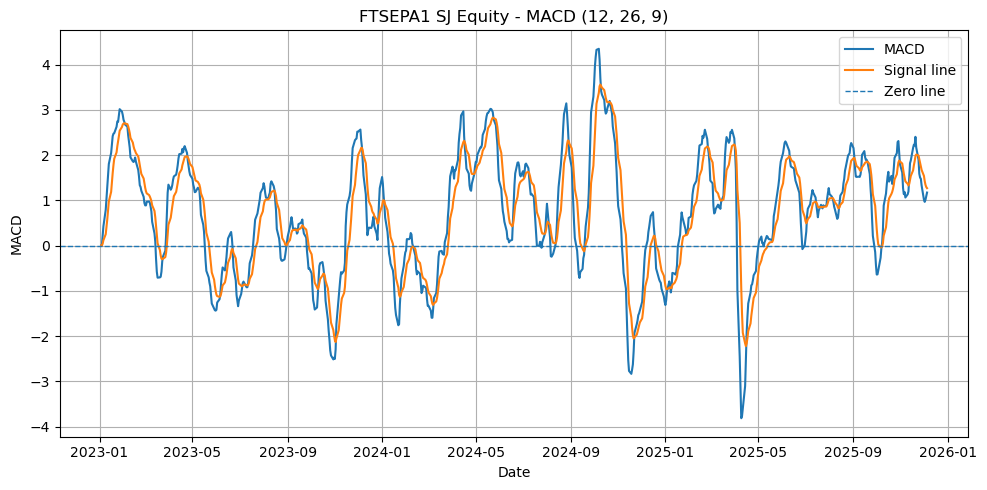

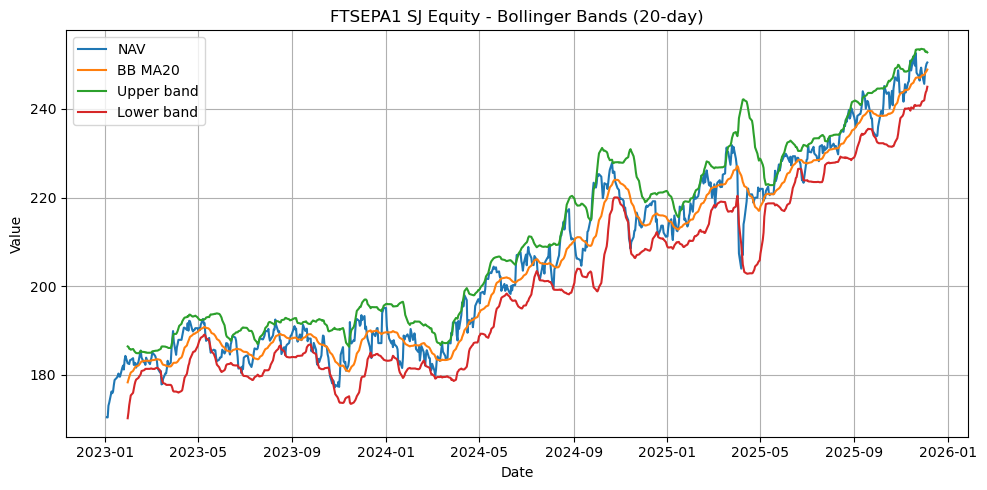


================ NEDGRPR SJ Equity ================



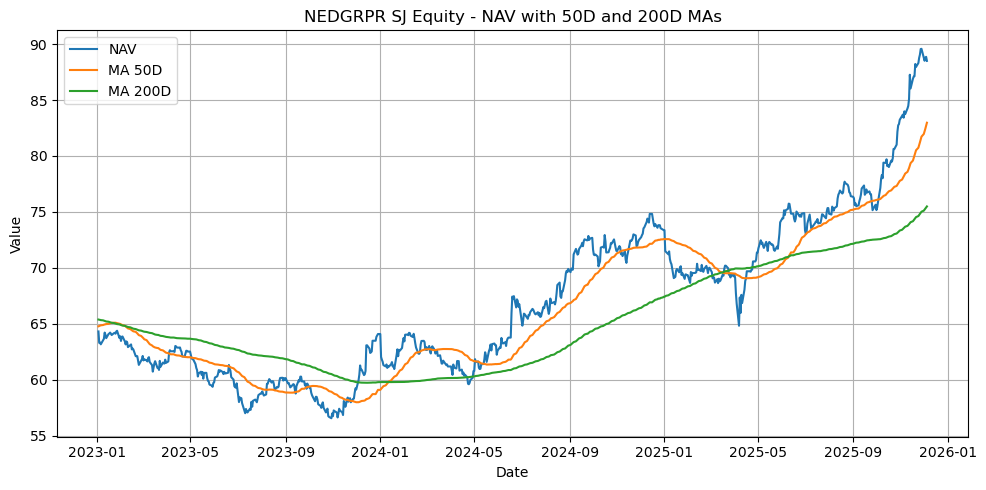

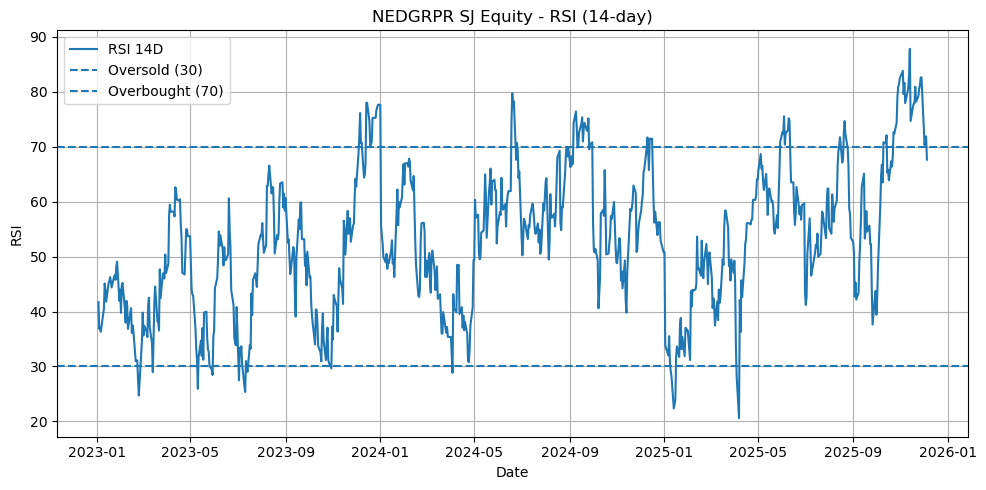

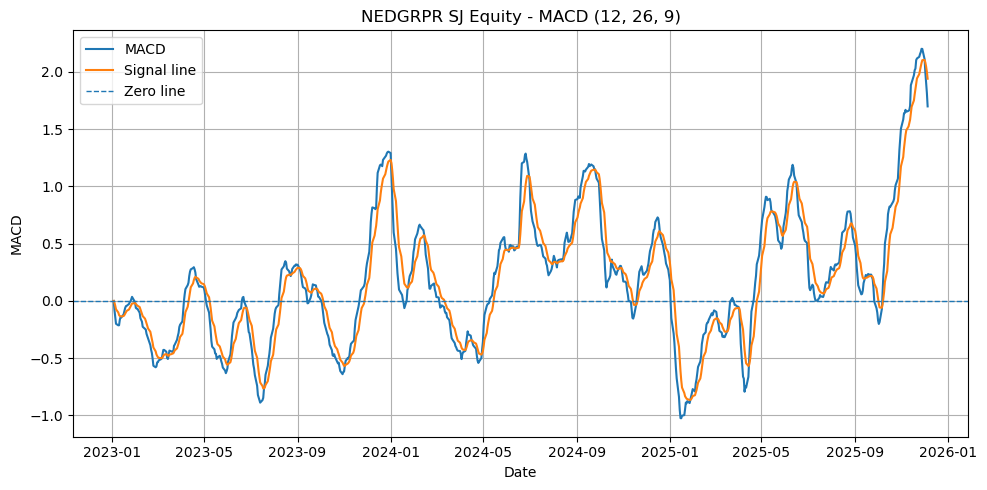

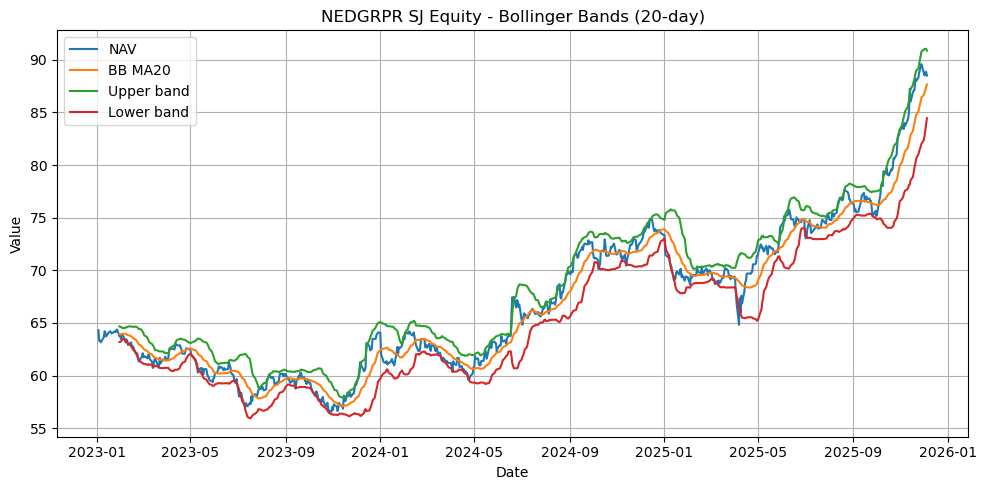


================ OLDMAGA SJ Equity ================



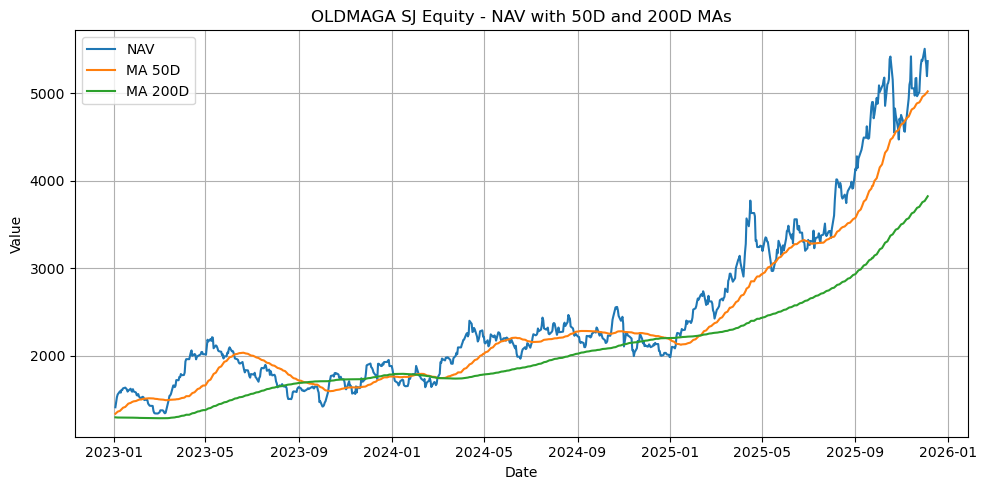

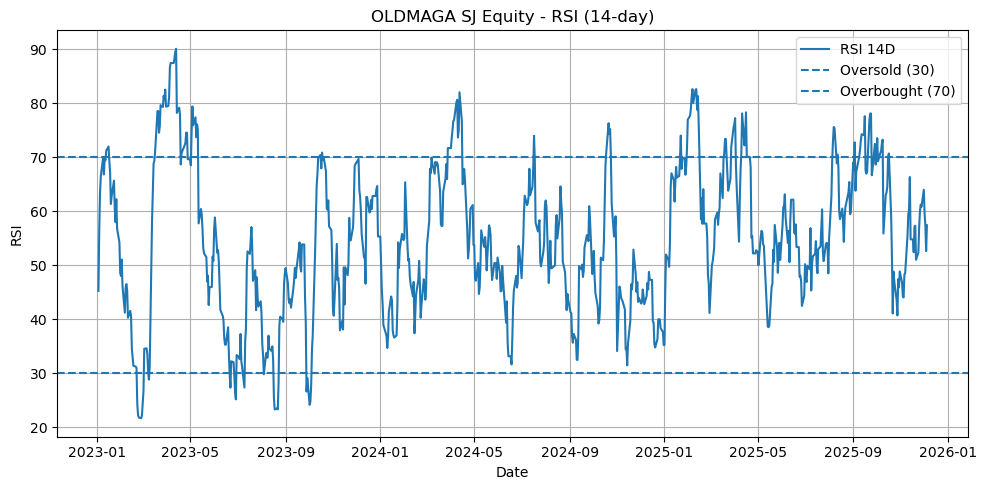

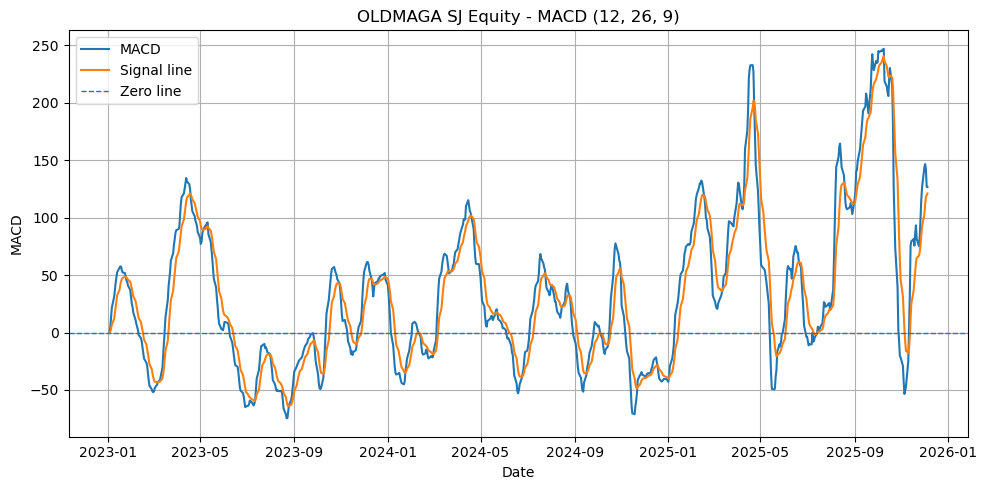

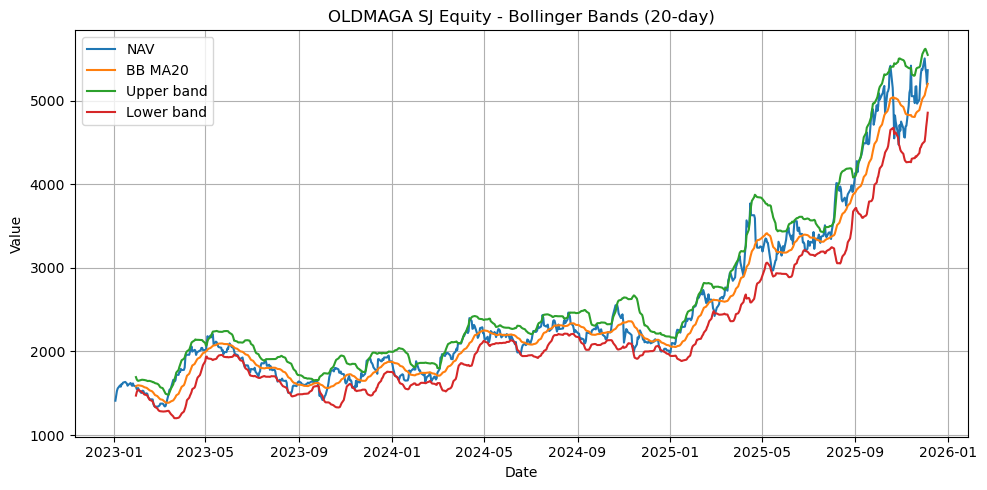


================ OLMEEAZ SJ Equity ================



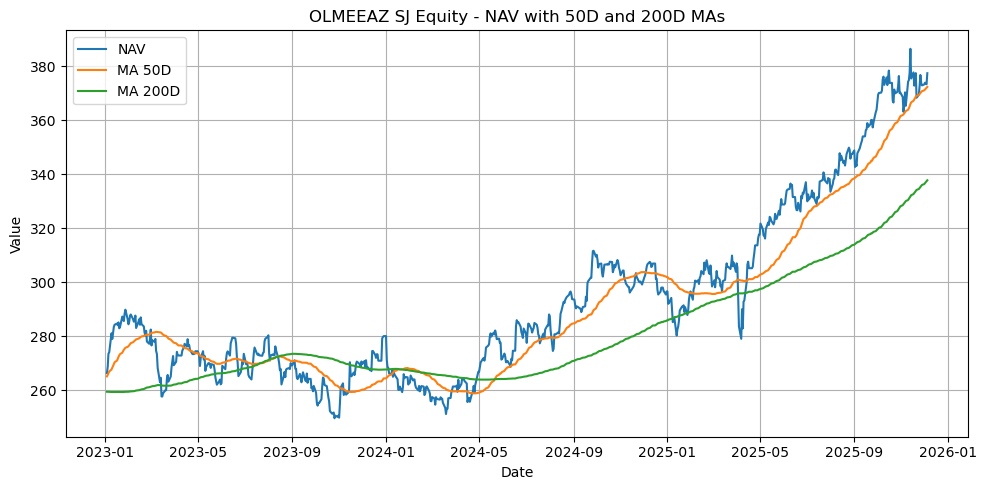

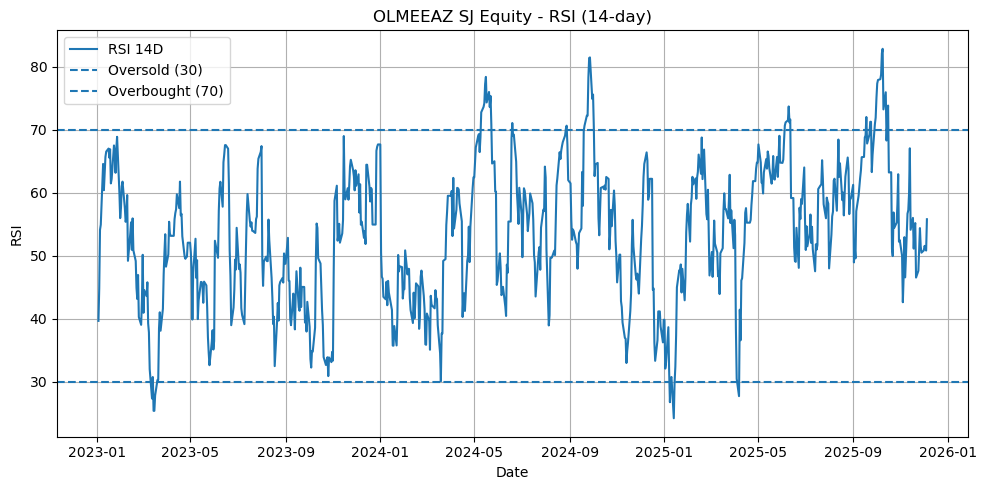

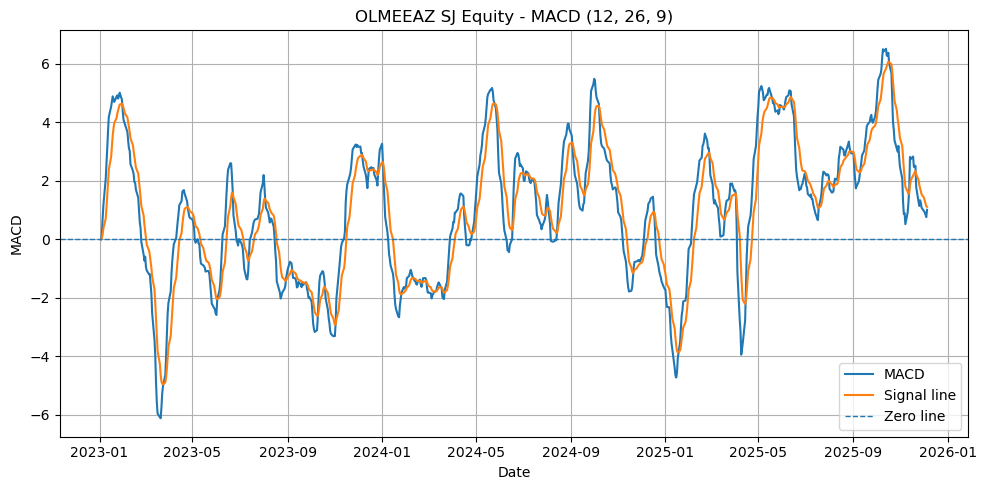

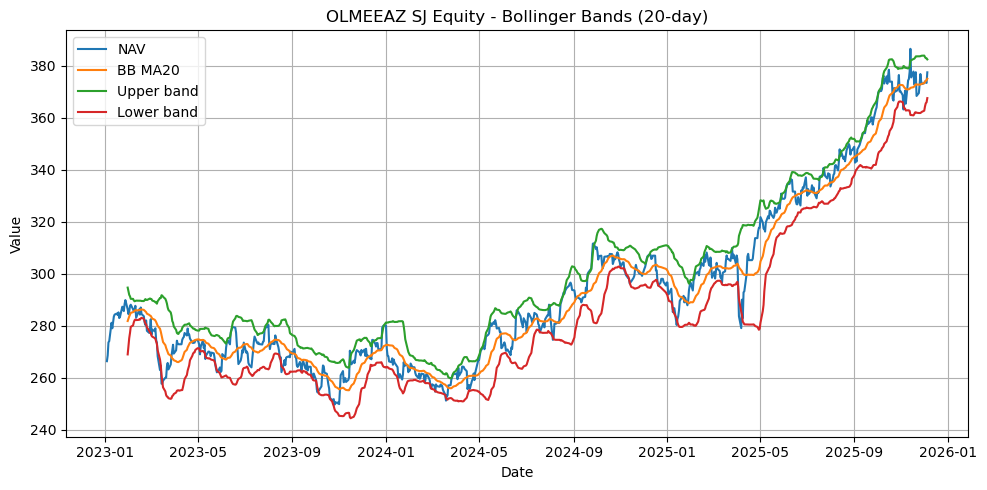


================ PRUHYBF SJ Equity ================



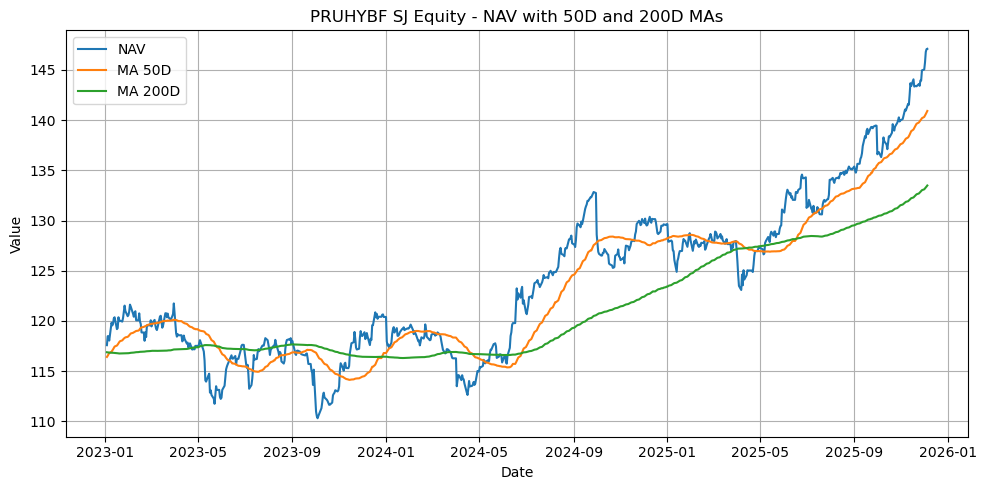

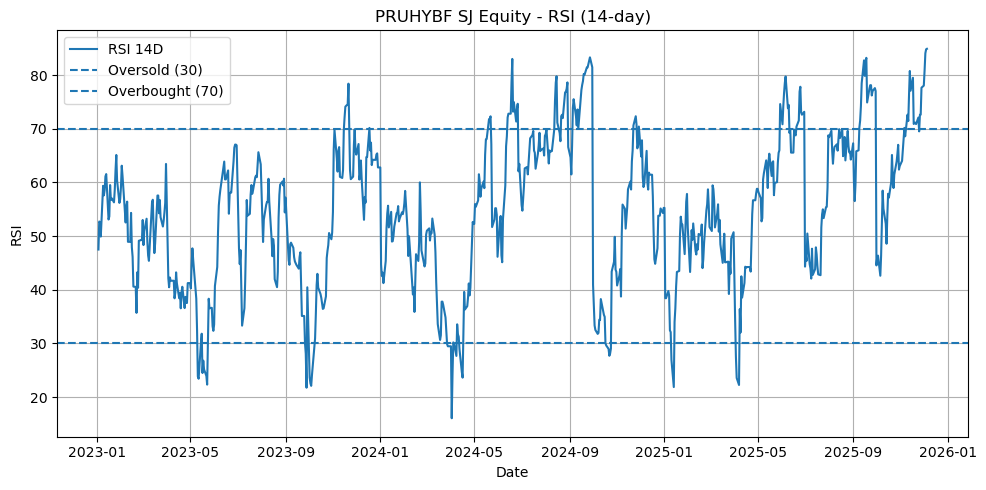

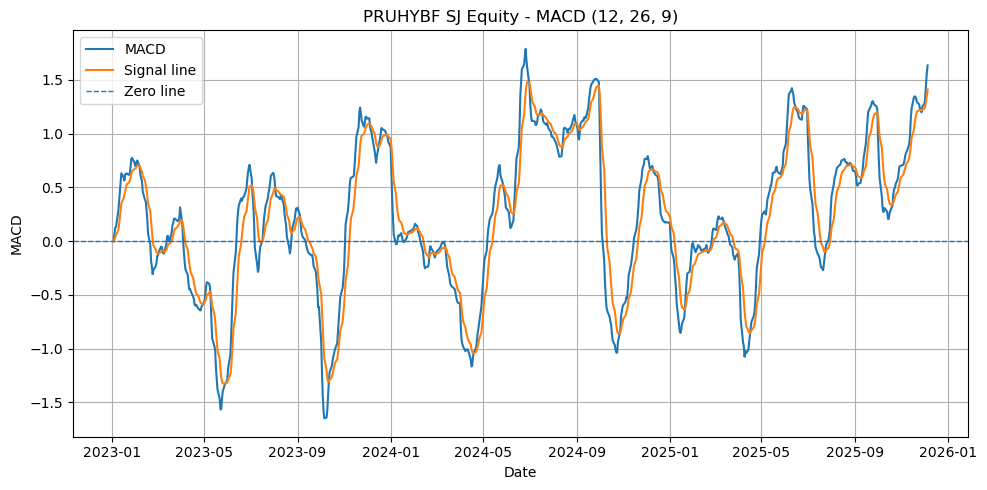

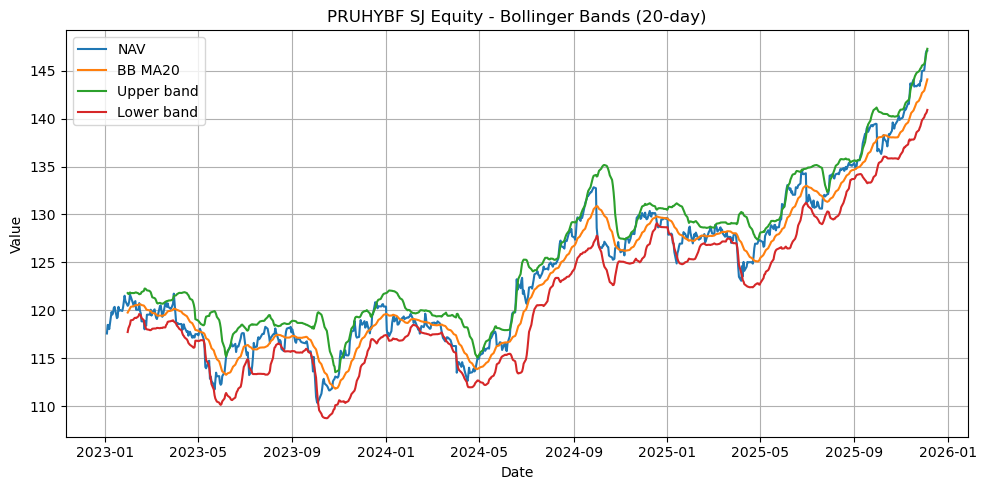

In [19]:
# STEP 13: Generate all technical-analysis plots for every fund

for name in fund_names:   # ['FTSEPA1 SJ Equity', ..., 'PRUHYBF SJ Equity']
    df = funds_ta[name]
    print(f"\n================ {name} ================\n")
    
    plot_price_and_mas(df)
    plot_rsi(df)
    plot_macd(df)
    plot_bollinger(df)
